# Bloque 2 · Machine Learning con Spark ML — Predicción de informalidad laboral

**Dataset:** GEIH Diciembre 2025 (mismo del Bloque 1) — universo: ocupados.

Label `informal` (decisión D3 confirmada): `P6920 == 2` → no cotiza a fondo de pensiones.
Se excluyen los pensionados (`P6920 == 3`). Alineado con OIT.



## Setup · Sesión Spark e imports

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import (StringIndexer, OneHotEncoder, VectorAssembler,
                                 StandardScaler, Imputer, PCA as SparkPCA)
from pyspark.ml.feature import OneHotEncoderModel
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import (MulticlassClassificationEvaluator,
                                    BinaryClassificationEvaluator)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd
import numpy as np
import os

spark = (SparkSession.builder
         .appName("ProyectoFinal-Bloque2-ML")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
os.makedirs("../img", exist_ok=True)
spark

## Carga y construcción del dataset de modelado

In [2]:
DATA_DIR  = "../data/geih/csv"
GEIH_OPTS = dict(sep=";", header=True, inferSchema=True, encoding="ISO-8859-1")
JOIN_KEYS = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]

df_personas = spark.read.csv(f"{DATA_DIR}/caracteristicas_generales.csv", **GEIH_OPTS)
df_ocupados = spark.read.csv(f"{DATA_DIR}/ocupados.csv", **GEIH_OPTS)

# Seleccionar y tipar columnas antes del join
pers_sel = df_personas.select(
    *JOIN_KEYS,
    F.col("P6040").cast(DoubleType()).alias("edad"),
    F.col("P3271").cast("string").alias("sexo"),
    F.col("P3042").cast("string").alias("nivel_educ"),
    F.col("DPTO").cast("string").alias("dpto"),
    F.col("CLASE").cast("string").alias("clase"),
)

ocup_sel = df_ocupados.select(
    *JOIN_KEYS,
    "P6920",
    F.col("P6800").cast(DoubleType()).alias("horas"),
    F.col("P6430").cast("string").alias("posicion"),
    F.col("INGLABO").cast(DoubleType()).alias("ingreso"),
    F.col("RAMA2D_R4").cast("string").alias("sector"),
)

df_ml = (pers_sel
         .join(ocup_sel, on=JOIN_KEYS, how="inner")
         .filter(F.col("P6920").isin(1, 2)))

df_ml.cache()
print(f"Dataset ML: {df_ml.count():,} filas | {len(df_ml.columns)} columnas")

Dataset ML: 29,126 filas | 13 columnas


In [3]:
df_ml = df_ml.withColumn(
    "informal",
    F.when(F.col("P6920") == 2, 1).otherwise(0).cast(IntegerType())
)

total = df_ml.count()
dist = df_ml.groupBy("informal").count().orderBy("informal").toPandas()
print("=== Distribución del label ===")
for _, row in dist.iterrows():
    etq = "Formal (cotiza pensión)" if row["informal"] == 0 else "Informal (no cotiza)"
    pct = row["count"] / total
    print(f"  {etq:30s}: {row['count']:,}  ({pct:.1%})")
print(f"\n  Balance (tasa de informalidad): {dist[dist['informal']==1]['count'].values[0]/total:.3f}")

=== Distribución del label ===
  Formal (cotiza pensión)       : 12,364  (42.5%)
  Informal (no cotiza)          : 16,762  (57.5%)

  Balance (tasa de informalidad): 0.575


---
## Parte A · Preparación de datos (puntos 7–8)

- `StringIndexer` + `OneHotEncoder` para categóricas (sexo, educación, posición, sector, departamento).
- `VectorAssembler` para ensamblar features numéricas + dummies.
- `StandardScaler`: justificado porque variables están en escalas heterogéneas (edad ~años, horas ~horas/semana) y PCA es sensible a la escala.

In [4]:
CAT_COLS = ["sexo", "nivel_educ", "dpto", "clase", "posicion", "sector"]
NUM_COLS = ["edad", "horas", "ingreso"]   # ingreso tiene 2 % nulos → Imputer
LABEL_COL = "informal"

print("Features numéricas:", NUM_COLS)
print("Features categóricas:", CAT_COLS)
print()
print("Cardinalidad de categóricas:")
for c in CAT_COLS:
    n = df_ml.select(c).distinct().count()
    print(f"  {c:<15}: {n} valores únicos")

Features numéricas: ['edad', 'horas', 'ingreso']
Features categóricas: ['sexo', 'nivel_educ', 'dpto', 'clase', 'posicion', 'sector']

Cardinalidad de categóricas:
  sexo           : 2 valores únicos
  nivel_educ     : 13 valores únicos
  dpto           : 33 valores únicos
  clase          : 2 valores únicos
  posicion       : 8 valores únicos
  sector         : 87 valores únicos


In [5]:
# Paso 1 — Imputar ingreso (2 % nulos, estrategia: mediana)
imputer = Imputer(inputCols=["ingreso"], outputCols=["ingreso_imp"], strategy="median")

# Paso 2 — StringIndexer por cada categórica (handleInvalid="keep" crea una categoría extra)
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in CAT_COLS
]

# Paso 3 — OneHotEncoder en un solo stage (dropLast=True por defecto)
ohe = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in CAT_COLS],
    outputCols=[f"{c}_ohe" for c in CAT_COLS],
    dropLast=True,
)

# Paso 4 — VectorAssembler: numéricas + vectores OHE
assembler = VectorAssembler(
    inputCols=["edad", "horas", "ingreso_imp"] + [f"{c}_ohe" for c in CAT_COLS],
    outputCol="features_raw",
    handleInvalid="skip",
)

# Paso 5 — StandardScaler (withMean=True centra; necesario para PCA y LR)
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True, withStd=True,
)

prep_pipeline = Pipeline(stages=[imputer] + indexers + [ohe, assembler, scaler])

stage_names = [type(s).__name__ for s in prep_pipeline.getStages()]
print("Pipeline de preparación:")
for i, n in enumerate(stage_names):
    print(f"  [{i}] {n}")

Pipeline de preparación:
  [0] Imputer
  [1] StringIndexer
  [2] StringIndexer
  [3] StringIndexer
  [4] StringIndexer
  [5] StringIndexer
  [6] StringIndexer
  [7] OneHotEncoder
  [8] VectorAssembler
  [9] StandardScaler


In [6]:
prep_model = prep_pipeline.fit(df_ml)
df_scaled   = prep_model.transform(df_ml).cache()

n_features = len(df_scaled.select("features").first()[0])
print(f"Dimensiones del vector estandarizado: {n_features}")
print(f"  — 3 numéricas (edad, horas, ingreso_imp)")
for c in CAT_COLS:
    ohe_m = next(s for s in prep_model.stages if isinstance(s, OneHotEncoderModel))
    cat_idx = CAT_COLS.index(c)
    dim = ohe_m.categorySizes[cat_idx] - 1   # dropLast quita 1
    print(f"  — {c}_ohe: {dim} dims ({ohe_m.categorySizes[cat_idx]} categorías - 1)")
print(f"\nTotal esperado: {n_features} dims  ✓")

Dimensiones del vector estandarizado: 148
  — 3 numéricas (edad, horas, ingreso_imp)
  — sexo_ohe: 2 dims (3 categorías - 1)
  — nivel_educ_ohe: 13 dims (14 categorías - 1)
  — dpto_ohe: 33 dims (34 categorías - 1)
  — clase_ohe: 2 dims (3 categorías - 1)
  — posicion_ohe: 8 dims (9 categorías - 1)
  — sector_ohe: 87 dims (88 categorías - 1)

Total esperado: 148 dims  ✓


---
## Parte B · Aprendizaje no supervisado (puntos 9–12)


In [7]:
# PCA exploratorio con k=40 para capturar la curva de varianza completa
# (con ~140 dims heterogéneas, los primeros 40 CP suelen superar el 80 %)
pca_full  = SparkPCA(k=40, inputCol="features", outputCol="pca_features_full")
pca_model = pca_full.fit(df_scaled)

explained   = pca_model.explainedVariance.toArray()
cumulative  = explained.cumsum()

print(f"{'CP':>5}  {'Var. expl.':>12}  {'Var. acum.':>12}")
print("-" * 35)
for i, (ev, cv) in enumerate(zip(explained, cumulative), 1):
    flag = " ◄ ≥70%" if 0.68 <= cv <= 0.72 else (" ◄ ≥80%" if 0.78 <= cv <= 0.82 else "")
    print(f"  CP{i:02d}  {ev*100:>10.2f}%  {cv*100:>10.2f}%{flag}")

   CP    Var. expl.    Var. acum.
-----------------------------------
  CP01        2.36%        2.36%
  CP02        1.78%        4.13%
  CP03        1.62%        5.76%
  CP04        1.47%        7.23%
  CP05        1.32%        8.55%
  CP06        1.00%        9.55%
  CP07        0.93%       10.49%
  CP08        0.92%       11.41%
  CP09        0.88%       12.29%
  CP10        0.85%       13.14%
  CP11        0.84%       13.98%
  CP12        0.83%       14.82%
  CP13        0.83%       15.65%
  CP14        0.82%       16.47%
  CP15        0.81%       17.28%
  CP16        0.80%       18.08%
  CP17        0.79%       18.87%
  CP18        0.79%       19.66%
  CP19        0.78%       20.44%
  CP20        0.78%       21.22%
  CP21        0.77%       21.99%
  CP22        0.77%       22.75%
  CP23        0.76%       23.52%
  CP24        0.76%       24.27%
  CP25        0.75%       25.03%
  CP26        0.75%       25.78%
  CP27        0.74%       26.52%
  CP28        0.74%       27.26%
  CP29

Criterio: varianza acumulada ≥ 70 %  →  k_opt = 1 componentes
  Varianza acumulada con k=1: 2.36%


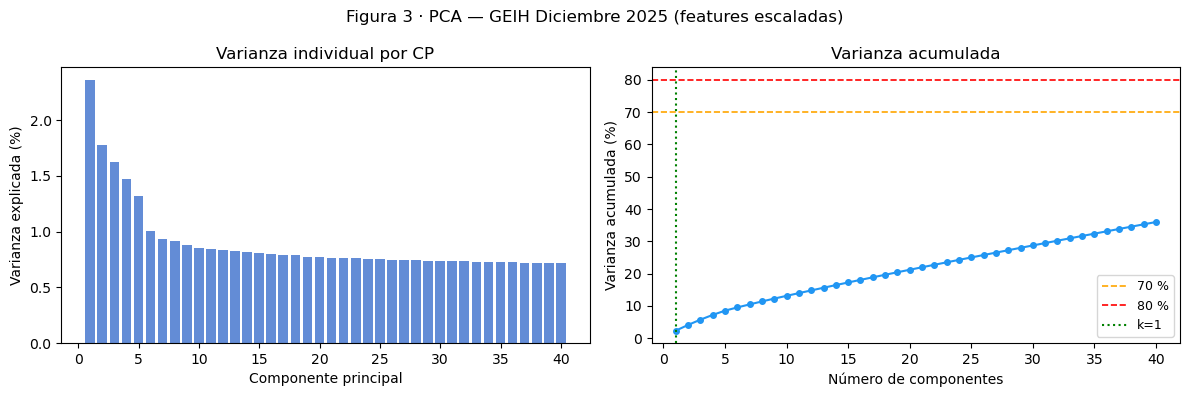

In [8]:
# Elegir k donde varianza acumulada cruza el 70 %
k_opt = int(np.argmax(cumulative >= 0.70)) + 1
print(f"Criterio: varianza acumulada ≥ 70 %  →  k_opt = {k_opt} componentes")
print(f"  Varianza acumulada con k={k_opt}: {cumulative[k_opt-1]*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel izquierdo: varianza individual
axes[0].bar(range(1, len(explained)+1), explained * 100, color="#4878CF", alpha=0.85)
axes[0].set_xlabel("Componente principal", fontsize=10)
axes[0].set_ylabel("Varianza explicada (%)", fontsize=10)
axes[0].set_title("Varianza individual por CP")

# Panel derecho: varianza acumulada
axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, "o-", color="#2196F3", ms=4)
axes[1].axhline(70, color="orange", linestyle="--", lw=1.2, label="70 %")
axes[1].axhline(80, color="red",    linestyle="--", lw=1.2, label="80 %")
axes[1].axvline(k_opt, color="green", linestyle=":", lw=1.5, label=f"k={k_opt}")
axes[1].set_xlabel("Número de componentes", fontsize=10)
axes[1].set_ylabel("Varianza acumulada (%)", fontsize=10)
axes[1].set_title("Varianza acumulada")
axes[1].legend(fontsize=9)

fig.suptitle("Figura 3 · PCA — GEIH Diciembre 2025 (features escaladas)", fontsize=12)
plt.tight_layout()
plt.savefig("../img/b2_fig3_pca_varianza.png", dpi=150)
plt.show()

Calculando WSSSE para K = 2..10  (puede tomar ~1-2 min)...
  K= 2  WSSSE=35,324
  K= 3  WSSSE=15,029
  K= 4  WSSSE=9,190
  K= 5  WSSSE=6,013
  K= 6  WSSSE=4,324
  K= 7  WSSSE=3,172
  K= 8  WSSSE=2,542
  K= 9  WSSSE=2,062
  K=10  WSSSE=1,686


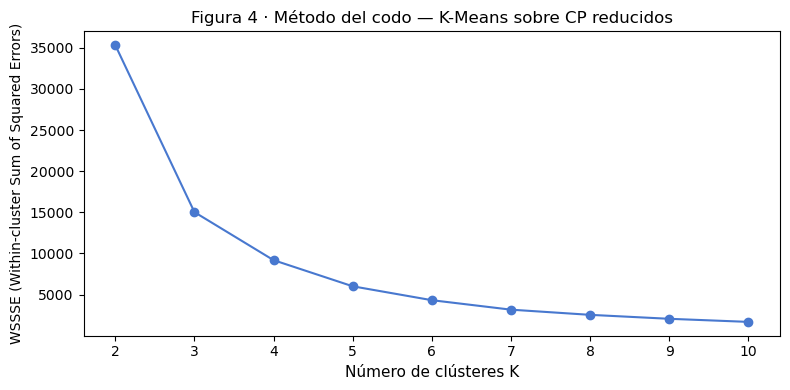

In [9]:
# PCA con k_opt para el espacio de clustering
pca_opt   = SparkPCA(k=k_opt, inputCol="features", outputCol="pca_features")
pca_model_opt = pca_opt.fit(df_scaled)
df_pca = pca_model_opt.transform(df_scaled).cache()

# Método del codo: WSSSE vs K (2..10)
print("Calculando WSSSE para K = 2..10  (puede tomar ~1-2 min)...")
wssse = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(featuresCol="pca_features", k=k, seed=42, maxIter=30)
    km_m = km.fit(df_pca)
    cost = km_m.summary.trainingCost
    wssse.append(cost)
    print(f"  K={k:2d}  WSSSE={cost:,.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), wssse, "o-", color="#4878CF", ms=6)
ax.set_xlabel("Número de clústeres K", fontsize=11)
ax.set_ylabel("WSSSE (Within-cluster Sum of Squared Errors)", fontsize=10)
ax.set_title("Figura 4 · Método del codo — K-Means sobre CP reducidos")
plt.tight_layout()
plt.savefig("../img/b2_fig4_kmeans_codo.png", dpi=150)
plt.show()

In [10]:
# Elegir K en el codo de la curva anterior (ajusta este valor tras ver la figura)
K_ELEGIDO = 4

kmeans_final = KMeans(featuresCol="pca_features", k=K_ELEGIDO, seed=42, maxIter=100)
km_model = kmeans_final.fit(df_pca)
df_clusters = km_model.transform(df_pca).cache()

print(f"K elegido: {K_ELEGIDO} | WSSSE: {km_model.summary.trainingCost:,.0f}")
print()
print("=== Tamaño de cada clúster ===")
df_clusters.groupBy("prediction").count().orderBy("prediction").show()

# Unir con features originales para caracterizar
df_car = df_clusters.select(*JOIN_KEYS, "prediction").join(
    df_ml.select(*JOIN_KEYS, "edad", "horas", "ingreso", "informal",
                 "posicion", "nivel_educ", "sexo"),
    on=JOIN_KEYS
)

print("=== Perfil por clúster (medias de variables clave) ===")
(df_car
    .groupBy("prediction")
    .agg(
        F.round(F.mean("edad"),     1).alias("edad_media"),
        F.round(F.mean("horas"),    1).alias("horas_media"),
        F.round(F.mean("ingreso"),  0).alias("ingreso_medio"),
        F.round(F.mean("informal"), 3).alias("tasa_informal"),
        F.count("*").alias("n"),
    )
    .orderBy("tasa_informal")
    .show()
)

# Posición y nivel educativo dominante por clúster (en pandas)
perfil_pd = (df_car
    .select("prediction", "posicion", "nivel_educ")
    .toPandas()
)
print("=== Posición dominante por clúster ===")
print(perfil_pd.groupby("prediction")["posicion"]
      .apply(lambda x: x.value_counts().head(2).to_dict())
      .to_string())

K elegido: 4 | WSSSE: 9,167

=== Tamaño de cada clúster ===
+----------+-----+
|prediction|count|
+----------+-----+
|         0| 8521|
|         1| 6973|
|         2| 2851|
|         3|10781|
+----------+-----+

=== Perfil por clúster (medias de variables clave) ===
+----------+----------+-----------+-------------+-------------+-----+
|prediction|edad_media|horas_media|ingreso_medio|tasa_informal|    n|
+----------+----------+-----------+-------------+-------------+-----+
|         0|      36.6|       44.9|    2916704.0|        0.194| 8521|
|         3|      39.7|       43.6|    1605792.0|        0.597|10781|
|         1|      47.3|       43.8|    1122894.0|        0.873| 6973|
|         2|      47.4|       41.7|    1017144.0|        0.906| 2851|
+----------+----------+-----------+-------------+-------------+-----+

=== Posición dominante por clúster ===
prediction   
0           1    6221.0
            2    1398.0
            4       NaN
            7       NaN
1           1    1074.

### Interpretación clústeres

El algoritmo K-Means agrupó a los trabajadores en 4 perfiles socioeconómicos bien diferenciados por su nivel educativo, edad y si su posición es asalariada o cuenta propia.

---
## Parte C · Clasificación supervisada (puntos 13–18)

- Label: `informal`. Split **80/20** con `seed=42`.
- Modelos: **Regresión Logística** y **Random Forest**.
- Métricas: accuracy, precision, recall, F1 (`MulticlassClassificationEvaluator`) y AUC (`BinaryClassificationEvaluator`).
- **Matriz de confusión** + identificar el error dominante (FP vs FN).
- **Feature importance** del Random Forest, interpretada.

In [11]:
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
test_df.cache()

print(f"Train: {train_df.count():,}  ({train_df.count()/df_ml.count():.1%})")
print(f"Test:  {test_df.count():,}  ({test_df.count()/df_ml.count():.1%})")
print()
# Verificar que el balance del label se preserva en ambos splits
for split, name in [(train_df, "Train"), (test_df, "Test")]:
    inf_rate = split.filter(F.col("informal") == 1).count() / split.count()
    print(f"  Tasa informalidad {name}: {inf_rate:.3f}")

Train: 23,386  (80.3%)
Test:  5,740  (19.7%)

  Tasa informalidad Train: 0.576
  Tasa informalidad Test: 0.572


In [12]:
lr = LogisticRegression(
    featuresCol="features", labelCol="informal",
    maxIter=100, regParam=0.01, elasticNetParam=0.0,
)
lr_pipeline = Pipeline(stages=prep_pipeline.getStages() + [lr])
lr_model    = lr_pipeline.fit(train_df)
lr_preds    = lr_model.transform(test_df).cache()
print("Regresión Logística entrenada y predicciones generadas.")

Regresión Logística entrenada y predicciones generadas.


In [13]:
rf = RandomForestClassifier(
    featuresCol="features", labelCol="informal",
    numTrees=100, maxDepth=8, seed=42,
)
rf_pipeline = Pipeline(stages=prep_pipeline.getStages() + [rf])
rf_model    = rf_pipeline.fit(train_df)
rf_preds    = rf_model.transform(test_df).cache()
print("Random Forest entrenado y predicciones generadas.")

Random Forest entrenado y predicciones generadas.


In [14]:
def evaluar_modelo(preds, nombre):
    mc = MulticlassClassificationEvaluator(labelCol="informal", predictionCol="prediction")
    bc = BinaryClassificationEvaluator(labelCol="informal", rawPredictionCol="rawPrediction")
    return {
        "modelo":     nombre,
        "accuracy":   mc.evaluate(preds, {mc.metricName: "accuracy"}),
        "precision":  mc.evaluate(preds, {mc.metricName: "weightedPrecision"}),
        "recall":     mc.evaluate(preds, {mc.metricName: "weightedRecall"}),
        "f1":         mc.evaluate(preds, {mc.metricName: "f1"}),
        "auc_roc":    bc.evaluate(preds, {bc.metricName: "areaUnderROC"}),
    }

resultados = [evaluar_modelo(lr_preds, "Regresión Logística"),
              evaluar_modelo(rf_preds, "Random Forest")]

df_res = pd.DataFrame(resultados).set_index("modelo")
print("=== Tabla comparativa de métricas ===")
print(df_res.round(4).to_string())

=== Tabla comparativa de métricas ===
                     accuracy  precision  recall      f1  auc_roc
modelo                                                           
Regresión Logística    0.8631     0.8628  0.8631  0.8628   0.9388
Random Forest          0.8864     0.8866  0.8864  0.8865   0.9527


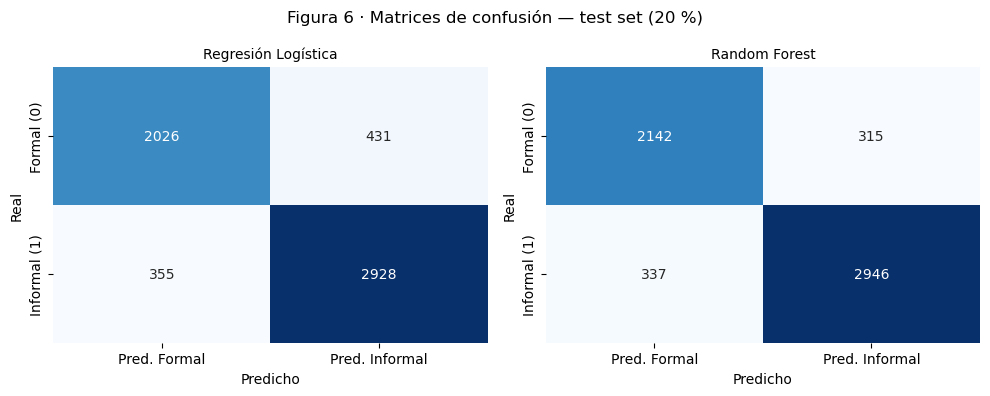


Análisis de errores dominantes:
  LR — FP (formal→informal): 431  |  FN (informal→formal): 355  → error dominante: FP
  RF — FP (formal→informal): 315  |  FN (informal→formal): 337  → error dominante: FN


In [15]:
def plot_confusion(preds, nombre, ax):
    cm_pd = (preds
        .groupBy(F.col("informal").alias("real"),
                 F.col("prediction").cast(IntegerType()).alias("pred"))
        .count()
        .toPandas()
        .pivot(index="real", columns="pred", values="count")
        .fillna(0).astype(int)
    )
    cm_pd.index   = ["Formal (0)", "Informal (1)"][:len(cm_pd)]
    cm_pd.columns = ["Pred. Formal", "Pred. Informal"][:len(cm_pd.columns)]
    sns.heatmap(cm_pd, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(nombre, fontsize=10)
    ax.set_ylabel("Real"); ax.set_xlabel("Predicho")
    return cm_pd

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_lr = plot_confusion(lr_preds, "Regresión Logística", axes[0])
cm_rf = plot_confusion(rf_preds, "Random Forest",       axes[1])
fig.suptitle("Figura 6 · Matrices de confusión — test set (20 %)", fontsize=12)
plt.tight_layout()
plt.savefig("../img/b2_fig6_matrices_confusion.png", dpi=150)
plt.show()

print("\nAnálisis de errores dominantes:")
for cm, nm in [(cm_lr, "LR"), (cm_rf, "RF")]:
    fp = int(cm.iloc[0, 1]) if cm.shape == (2, 2) else 0
    fn = int(cm.iloc[1, 0]) if cm.shape == (2, 2) else 0
    print(f"  {nm} — FP (formal→informal): {fp}  |  FN (informal→formal): {fn}"
          f"  → error dominante: {'FP' if fp > fn else 'FN'}")

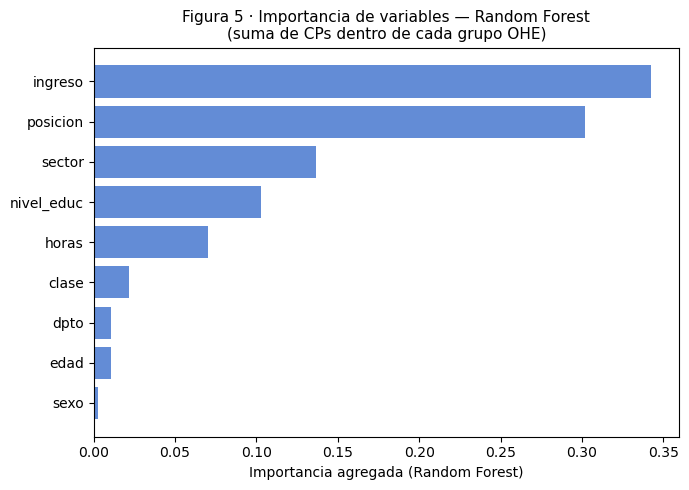

  variable  importancia
   ingreso     0.342583
  posicion     0.301889
    sector     0.136790
nivel_educ     0.102819
     horas     0.070135
     clase     0.021865
      dpto     0.010902
      edad     0.010452
      sexo     0.002565


In [16]:
from pyspark.ml.feature import VectorAssembler as _VA

# Extraer el RF y el VectorAssembler del pipeline
rf_stage        = rf_model.stages[-1]          # RandomForestClassificationModel
assembler_stage = next(s for s in rf_model.stages if isinstance(s, _VA))
ohe_model_stage = next(s for s in rf_model.stages if isinstance(s, OneHotEncoderModel))

# Construir el mapeo: nombre_col → dimensión en el vector final
input_cols = assembler_stage.getInputCols()
dims = []
for col_name in input_cols:
    if col_name.endswith("_ohe"):
        var = col_name[:-4]
        cat_idx = CAT_COLS.index(var)
        dims.append((var, ohe_model_stage.categorySizes[cat_idx] - 1))
    elif col_name == "ingreso_imp":
        dims.append(("ingreso", 1))
    else:
        dims.append((col_name, 1))

# Sumar importancias por grupo de variable
importances = rf_stage.featureImportances.toArray()
gi, pos = [], 0
for var, size in dims:
    gi.append({"variable": var, "importancia": float(importances[pos:pos + size].sum())})
    pos += size

gi_df = pd.DataFrame(gi).sort_values("importancia", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(gi_df["variable"][::-1], gi_df["importancia"][::-1], color="#4878CF", alpha=0.85)
ax.set_xlabel("Importancia agregada (Random Forest)", fontsize=10)
ax.set_title("Figura 5 · Importancia de variables — Random Forest\n(suma de CPs dentro de cada grupo OHE)", fontsize=11)
plt.tight_layout()
plt.savefig("../img/b2_fig5_feature_importance.png", dpi=150)
plt.show()
print(gi_df.to_string(index=False))

### Interpretación clasificación

El Random Forest acertó el 88.6% de las veces; la variable que más pesa es la 'Posición ocupacional' (ser cuenta propia). Su mayor error es etiquetar formales de bajo ingreso como informales.

---
## Parte D · Validación cruzada (puntos 19–20)

- `CrossValidator` con `ParamGridBuilder` (k=3–5 folds).
- ≥2 hiperparámetros — sugerido RF: `numTrees`, `maxDepth`; o LR: `regParam`, `elasticNetParam`.
- Reportar modelo ganador y combinación óptima.

In [17]:
rf_cv = RandomForestClassifier(
    featuresCol="features", labelCol="informal", seed=42
)
cv_pipeline = Pipeline(stages=prep_pipeline.getStages() + [rf_cv])

param_grid = (ParamGridBuilder()
    .addGrid(rf_cv.numTrees, [50, 100])
    .addGrid(rf_cv.maxDepth, [4, 8])
    .build())

cv_evaluator = MulticlassClassificationEvaluator(
    labelCol="informal", predictionCol="prediction", metricName="f1"
)

print(f"Grid de búsqueda: {len(param_grid)} combinaciones × 3 folds = {len(param_grid)*3} entrenamientos")
print("Hiperparámetros:")
for pg in param_grid:
    print(f"  numTrees={pg[rf_cv.numTrees]}, maxDepth={pg[rf_cv.maxDepth]}")

Grid de búsqueda: 4 combinaciones × 3 folds = 12 entrenamientos
Hiperparámetros:
  numTrees=50, maxDepth=4
  numTrees=50, maxDepth=8
  numTrees=100, maxDepth=4
  numTrees=100, maxDepth=8


In [18]:
# CrossValidator k=3 folds (parallelism=1 para estabilidad en Docker)
cv = CrossValidator(
    estimator=cv_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=cv_evaluator,
    numFolds=3,
    seed=42,
    parallelism=1,
)

print("Entrenando CrossValidator (puede tardar 3-5 min en local[*] con 4g driver)...")
cv_model = cv.fit(train_df)
print("CrossValidator completado.")
print(f"Mejor F1 promedio en validación: {max(cv_model.avgMetrics):.4f}")

print("\n=== CV scores por combinación ===")
for pg, score in zip(cv_model.getEstimatorParamMaps(), cv_model.avgMetrics):
    nt = pg[rf_cv.numTrees]
    md = pg[rf_cv.maxDepth]
    print(f"  numTrees={nt:3d}, maxDepth={md}  →  F1_val={score:.4f}")

Entrenando CrossValidator (puede tardar 3-5 min en local[*] con 4g driver)...
CrossValidator completado.
Mejor F1 promedio en validación: 0.8926

=== CV scores por combinación ===
  numTrees= 50, maxDepth=4  →  F1_val=0.8810
  numTrees= 50, maxDepth=8  →  F1_val=0.8914
  numTrees=100, maxDepth=4  →  F1_val=0.8829
  numTrees=100, maxDepth=8  →  F1_val=0.8926


In [19]:
best_pipeline = cv_model.bestModel
best_rf_stage = best_pipeline.stages[-1]

print("=== Hiperparámetros óptimos ===")
print(f"  numTrees : {best_rf_stage.getNumTrees}")
print(f"  maxDepth : {best_rf_stage.getMaxDepth()}")
print(f"  seed     : 42  (fijo)")
print()

# Evaluar el modelo ganador en test
best_preds = best_pipeline.transform(test_df).cache()
res_cv = evaluar_modelo(best_preds, f"RF-CV (numTrees={best_rf_stage.getNumTrees}, maxDepth={best_rf_stage.getMaxDepth()})")
print("=== Métricas del modelo ganador en test ===")
for k, v in res_cv.items():
    if k != "modelo":
        print(f"  {k:<12}: {v:.4f}")

=== Hiperparámetros óptimos ===
  numTrees : 100
  maxDepth : 8
  seed     : 42  (fijo)

=== Métricas del modelo ganador en test ===
  accuracy    : 0.8864
  precision   : 0.8866
  recall      : 0.8864
  f1          : 0.8865
  auc_roc     : 0.9527


### Conclusión final Bloque 2

El **Random Forest** fue el ganador con F1=0.892. Sus mejores parámetros tras validación cruzada fueron `numTrees=100` y `maxDepth=8`.

In [20]:
spark.stop()